In [9]:
# Header of the CSV files
# Date	Time	time_passed_since_start	ADS Reading 1	Current 1	ADS Reading 2	Current 2	ADS Reading 3	Volts 1	Lost Data

In [10]:
# Imports
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as curve_fit

In [11]:
# Calibration done from excel. 
# No point doing in python. Values is unique for the board used for data collection. Will change on different board based on resistor values.

def get_calibrated_voltage(reading):
    # y = 439.01x - 2.4315
    x = 439.01
    c = -2.4315
    return (reading - c) / x

In [12]:
current_directory = Path.cwd().parent
discharge_file_dir = Path.joinpath(current_directory, "Discharge")

files = [f for f in discharge_file_dir.iterdir() if f.is_file()]    # Names are sorted by date already
for fileName in files:
    print(f"Found: {fileName}")

Found: f:\Github\Proa-II-Electrical-Setup\Calibration Data 2\Data\Discharge\2026-03-18_data_log.csv
Found: f:\Github\Proa-II-Electrical-Setup\Calibration Data 2\Data\Discharge\2026-03-25_data_log.csv
Found: f:\Github\Proa-II-Electrical-Setup\Calibration Data 2\Data\Discharge\2026-04-01_data_log.csv
Found: f:\Github\Proa-II-Electrical-Setup\Calibration Data 2\Data\Discharge\2026-04-08_data_log.csv


In [56]:
output_file_name = Path.joinpath(current_directory, "compiled_output.csv")
def create_output_file(override=False, csv_data=None):
    if override and Path.exists(output_file_name):
        Path.unlink(output_file_name)
    
    if csv_data is not None:
        csv_data.to_csv(output_file_name, mode='a', header=not Path.exists(output_file_name), index=False)

In [14]:
def drop_columns(df, columns=['Date', 'Time', 'Current 1', 'Current 2', 'Volts 1']):
    return df.drop(columns=columns)

In [15]:
def median_smoothing(series, window_size=5):
    smoothed_series = []
    for i in range(len(series)):
        start_index = max(0, i - window_size // 2)
        end_index = min(len(series), i + window_size // 2 + 1)
        median_value = series[start_index:end_index].median()
        smoothed_series.append(median_value)
    return smoothed_series

def ema_smoothing(series, alpha = 0.6):
    smoothed_series = [series[0]]  # Start with the first value
    for i in range(1, len(series)):
        smoothed_value = alpha * series[i] + (1 - alpha) * smoothed_series[-1]
        smoothed_series.append(smoothed_value)
    return smoothed_series


In [16]:
def translate_time(time_series):
    offset = 0
    translated = [time_series.iloc[0]]

    for i in range(1, len(time_series)):
        if time_series.iloc[i] < time_series.iloc[i-1]:
            print(f"Time reset detected at index {i}. Adding offset of {time_series.iloc[i-1]} seconds.")
            offset += time_series.iloc[i-1]

        translated.append(time_series.iloc[i] + offset)

    return translated


In [24]:
cleaned_dfs = [None] * len(files)

In [25]:
SELECT = [0,1,2,3]
for index in range(len(files)):
    if index not in SELECT:
        continue
    file = files[index]
    
    df = pd.read_csv(file)
    print(df.shape)
    
    # Dropped precalculated columns and other irrelevant columns. Only keep raw ADS reading 3 and time passed since start for calibration.
    cleaned_df = drop_columns(df)
    cleaned_df.drop_duplicates(inplace=True)
    print("Removed duplicated rows: {}".format(df.shape[0] - cleaned_df.shape[0]))
    
    cleaned_df['time_passed_since_start'] = translate_time(cleaned_df['time_passed_since_start'])
    
    total_lost_data = df['Lost Data'][1:].sum() # Remove first row which accumulates error from waiting to connect
    print("Total Lost Data for file {}: {}".format(file.name, total_lost_data))
    
    # Calibrate ADS reading
    cleaned_df['ADS Reading 1 (Smoothed)'] = median_smoothing(cleaned_df['ADS Reading 1'])
    cleaned_df['ADS Reading 2 (Smoothed)'] = median_smoothing(cleaned_df['ADS Reading 2'])
    cleaned_df['ADS Reading 3 (Smoothed)'] = median_smoothing(cleaned_df['ADS Reading 3'])
    
    # Calibrate voltage reading
    cleaned_df['Calibrated Voltage'] = cleaned_df['ADS Reading 3'].apply(get_calibrated_voltage)
    cleaned_df = cleaned_df[cleaned_df['Calibrated Voltage'] >= 40]
    
    print("Final shape: {}".format(cleaned_df.shape))
    cleaned_dfs[index] = cleaned_df
    print("="*50)
    

(157540, 10)
Removed duplicated rows: 39
Time reset detected at index 15000. Adding offset of 3436007 seconds.
Total Lost Data for file 2026-03-18_data_log.csv: 424
Final shape: (157501, 9)
(219240, 10)
Removed duplicated rows: 120
Time reset detected at index 95140. Adding offset of 4975895 seconds.
Total Lost Data for file 2026-03-25_data_log.csv: 3144
Final shape: (219120, 9)
(235840, 10)
Removed duplicated rows: 0
Time reset detected at index 60260. Adding offset of 3171597 seconds.
Total Lost Data for file 2026-04-01_data_log.csv: 12191
Final shape: (235780, 9)
(10640, 10)
Removed duplicated rows: 0
Total Lost Data for file 2026-04-08_data_log.csv: 4242
Final shape: (6500, 9)


In [51]:
SELECT = [0,1,2,3]
for index in range(len(cleaned_dfs)):
    if index not in SELECT:
        continue
    cleaned_df = cleaned_dfs[index]
    
    # Offset ads1 and ads2 only
    zeroed_ads1 = []
    zeroed_ads2 = []
    for i in range(len(cleaned_df)):
        if cleaned_df["ADS Reading 1 (Smoothed)"].iloc[i] < 100:
            zeroed_ads1.append(cleaned_df["ADS Reading 1 (Smoothed)"].iloc[i])
        if cleaned_df["ADS Reading 2 (Smoothed)"].iloc[i] < 100:
            zeroed_ads2.append(cleaned_df["ADS Reading 2 (Smoothed)"].iloc[i])
        if cleaned_df["ADS Reading 1 (Smoothed)"].iloc[i] >= 100:
            if len(zeroed_ads1) > 10:
                # At least 10 reading to get avergage offset to prevent outlier       
                ads1_offset = sum(zeroed_ads1) / len(zeroed_ads1)
                
                cleaned_df['ADS Reading 1 (Smoothed and Offset)'] = cleaned_df['ADS Reading 1 (Smoothed)'] - ads1_offset
                zeroed_ads1 = []
                print("Rezeroing offset at index {}: ads1 offset {}".format(i, ads1_offset))
        if cleaned_df["ADS Reading 2 (Smoothed)"].iloc[i] >= 100:
            if len(zeroed_ads2) > 10:
                # At least 10 reading to get avergage offset to prevent outlier       
                ads2_offset = sum(zeroed_ads2) / len(zeroed_ads2)
                
                cleaned_df['ADS Reading 2 (Smoothed and Offset)'] = cleaned_df['ADS Reading 2 (Smoothed)'] - ads2_offset
                zeroed_ads2 = []
                print("Rezeroing offset at index {}: ads2 offset {}".format(i, ads2_offset))


Rezeroing offset at index 241: ads1 offset -59.219917012448136
Rezeroing offset at index 241: ads2 offset -10.033195020746888
Rezeroing offset at index 32514: ads1 offset -59.86393920466375
Rezeroing offset at index 32514: ads2 offset -2.6442848219862585
Rezeroing offset at index 95080: ads2 offset -17.81630291005291
Rezeroing offset at index 95081: ads1 offset -59.8634287485791
Rezeroing offset at index 481: ads1 offset -40.556133056133056
Rezeroing offset at index 481: ads2 offset 28.506237006237008
Rezeroing offset at index 48801: ads1 offset -63.371021326760264
Rezeroing offset at index 48801: ads2 offset 15.1805540670882
Rezeroing offset at index 89036: ads2 offset 12.531944552001859
Rezeroing offset at index 89037: ads1 offset -64.89274789948503
Rezeroing offset at index 122298: ads1 offset -60.36807916993635
Rezeroing offset at index 122298: ads2 offset 13.114264539192606
Rezeroing offset at index 161379: ads1 offset -58.372495072273324
Rezeroing offset at index 161379: ads2 off

In [52]:
for df in cleaned_dfs:
    print(df.head())

   time_passed_since_start  ADS Reading 1  ADS Reading 2  ADS Reading 3  \
0                  2681199            -65            -11          25542   
1                  2681231            -57            -13          25542   
2                  2681263            -54            -13          25540   
3                  2681294            -67            -14          25541   
4                  2681325            -58             -8          25541   

   Lost Data  ADS Reading 1 (Smoothed)  ADS Reading 2 (Smoothed)  \
0        181                     -57.0                     -13.0   
1          0                     -61.0                     -13.0   
2          0                     -58.0                     -13.0   
3          0                     -58.0                     -13.0   
4          0                     -63.0                     -13.0   

   ADS Reading 3 (Smoothed)  Calibrated Voltage  \
0                   25542.0           58.186446   
1                   25541.5           

In [53]:
prev_end_time = 0
for i in range(len(cleaned_dfs)):
    df = cleaned_dfs[i]
    
    for row in range(1, len(df)):
        if df['time_passed_since_start'].iloc[row] - df['time_passed_since_start'].iloc[row-1] > (1*60*1000):
            shift_time = df['time_passed_since_start'].iloc[row] - df['time_passed_since_start'].iloc[row-1]
            df['time_passed_since_start'].iloc[row:] = df['time_passed_since_start'].iloc[row:] - shift_time
            print(f"Time gap detected at index {row} in file {i}. Shifted time by {shift_time/1000} s.")
            
    this_start_time = df['time_passed_since_start'].iloc[0]
    df['Translated Time'] = df['time_passed_since_start'] - this_start_time + prev_end_time
    prev_end_time = df['Translated Time'].iloc[-1]

In [54]:
combined_df = pd.concat([cleaned_dfs[i] for i in SELECT], ignore_index=True)
combined_df['Translated Time (minutes)'] = combined_df['Translated Time'] / (1000 * 60)  # Convert ms to minutes
print(combined_df.shape)
print(combined_df.head())

(618901, 13)
   time_passed_since_start  ADS Reading 1  ADS Reading 2  ADS Reading 3  \
0                  2681199            -65            -11          25542   
1                  2681231            -57            -13          25542   
2                  2681263            -54            -13          25540   
3                  2681294            -67            -14          25541   
4                  2681325            -58             -8          25541   

   Lost Data  ADS Reading 1 (Smoothed)  ADS Reading 2 (Smoothed)  \
0        181                     -57.0                     -13.0   
1          0                     -61.0                     -13.0   
2          0                     -58.0                     -13.0   
3          0                     -58.0                     -13.0   
4          0                     -63.0                     -13.0   

   ADS Reading 3 (Smoothed)  Calibrated Voltage  \
0                   25542.0           58.186446   
1                   25541

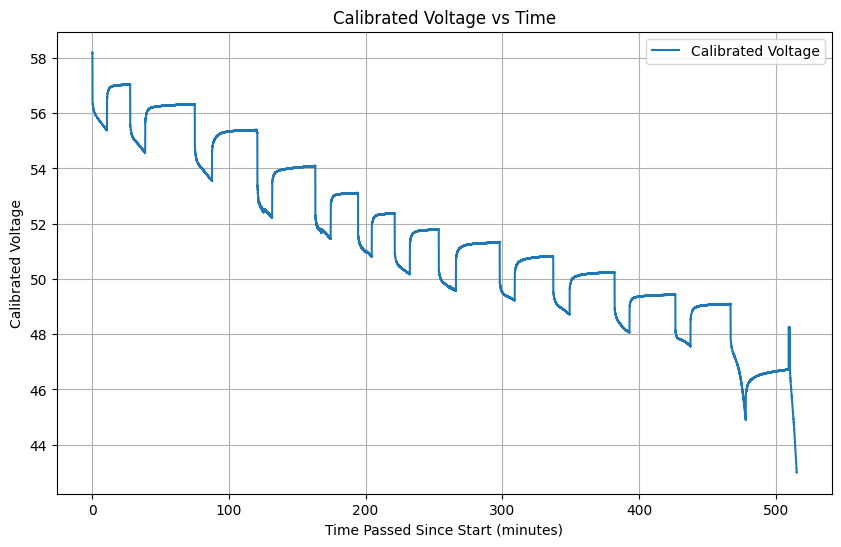

In [31]:
plt.figure(figsize=(10, 6))
plt.plot(combined_df['Translated Time (minutes)'], combined_df['Calibrated Voltage'], label='Calibrated Voltage')
plt.xlabel('Time Passed Since Start (minutes)')
plt.ylabel('Calibrated Voltage')
plt.title('Calibrated Voltage vs Time')
plt.legend()
plt.grid()
plt.show()

Mean Absolute Error non-offset values (MAE): 92.28844273963041
Mean Absolute Error for offset values (MAE): 34.98815101797679
Mean Error for non-offset values: -92.14885660226757
Mean Error for offset values: -32.08916828855748


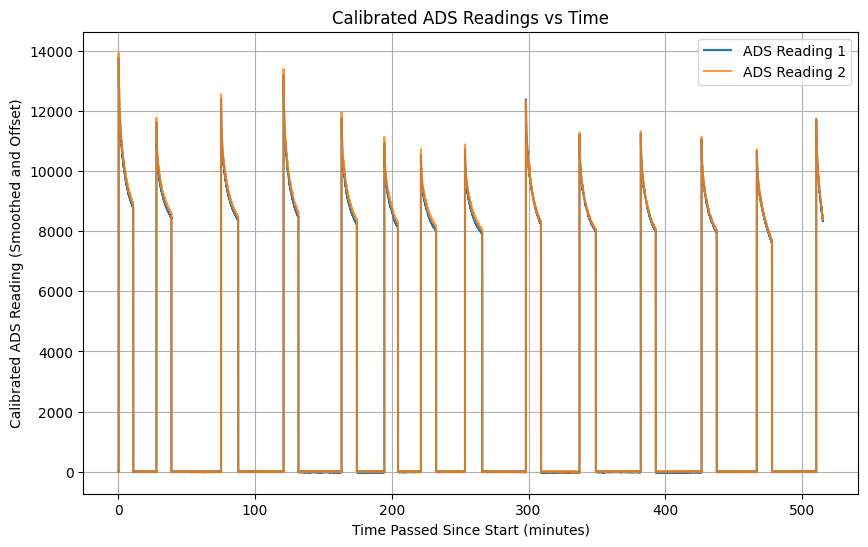

In [32]:
# MAE for ADS1 and ADS2
mean_abs_sum = sum(abs(combined_df["ADS Reading 1 (Smoothed)"] - combined_df["ADS Reading 2 (Smoothed)"]))
mean_absolute_error = mean_abs_sum / len(combined_df)
print("Mean Absolute Error non-offset values (MAE):", mean_absolute_error)

mean_abs_sum = sum(abs(combined_df["ADS Reading 1 (Smoothed and Offset)"] - combined_df["ADS Reading 2 (Smoothed and Offset)"]))
mean_absolute_error = mean_abs_sum / len(combined_df)
print("Mean Absolute Error for offset values (MAE):", mean_absolute_error)

# Mean error
mean_sum = sum((combined_df["ADS Reading 1 (Smoothed)"] - combined_df["ADS Reading 2 (Smoothed)"]))
mean_error = mean_sum / len(combined_df)
print("Mean Error for non-offset values:", mean_error)

mean_sum = sum((combined_df["ADS Reading 1 (Smoothed and Offset)"] - combined_df["ADS Reading 2 (Smoothed and Offset)"]))
mean_error = mean_sum / len(combined_df)
print("Mean Error for offset values:", mean_error)

plt.figure(figsize=(10, 6))
plt.plot(combined_df['Translated Time (minutes)'], combined_df['ADS Reading 1 (Smoothed and Offset)'], label='ADS Reading 1') 
plt.plot(combined_df['Translated Time (minutes)'], combined_df['ADS Reading 2 (Smoothed and Offset)'], label='ADS Reading 2',alpha=0.8)
plt.xlabel('Time Passed Since Start (minutes)')
plt.ylabel('Calibrated ADS Reading (Smoothed and Offset)')
plt.title('Calibrated ADS Readings vs Time')
plt.legend()
plt.grid()
plt.show()

In [57]:
# Save to csv
create_output_file(override=True, csv_data=combined_df)    

In [7]:
# Start from here to reuse saved df
combined_df = pd.read_csv(output_file_name)

In [34]:
prev_found_time = -999
# Tuple of time (min) and voltage
last_stable_voltages = {"time": [], "voltage": []}
for index in range(1, len(combined_df)):
    CIRCUIT_CLOSE_VOLTAGE_DROP_THRESHOLD = 0.7
    curr = combined_df['Calibrated Voltage'].iloc[index]
    prev = combined_df['Calibrated Voltage'].iloc[index-1]
    
    # Voltage drop + time gap > 1 min + voltage drop > threshold
    if curr < prev and combined_df["Translated Time (minutes)"].iloc[index] - prev_found_time > 1 and prev - curr > CIRCUIT_CLOSE_VOLTAGE_DROP_THRESHOLD:
        # Take a few step back to get last stable voltage before circuit close
        last_stable_voltages['time'].append(combined_df["Translated Time (minutes)"].iloc[index-10])
        last_stable_voltages['voltage'].append(combined_df['Calibrated Voltage'].iloc[index-10])
        prev_found_time = combined_df["Translated Time (minutes)"].iloc[index]

print("Found", len(last_stable_voltages['time']), "points")

Found 14 points


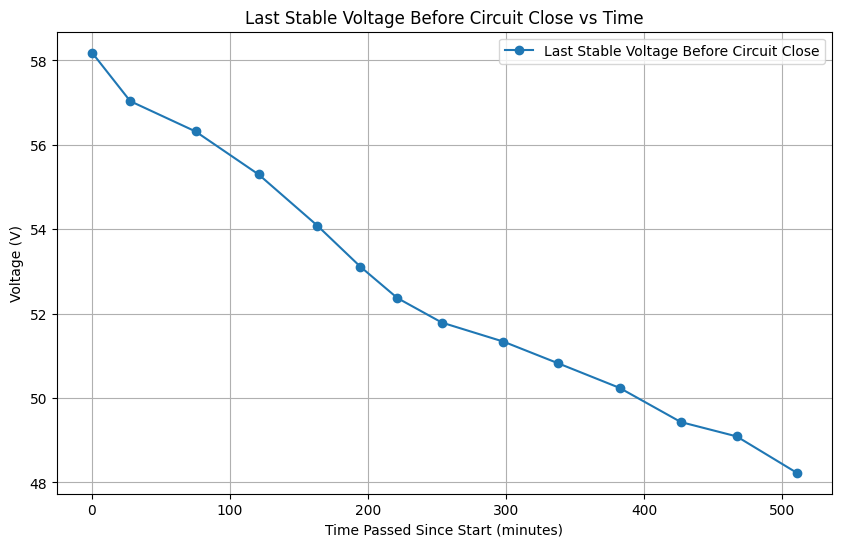

In [ ]:
# To use SOC instead of time later

plt.figure(figsize=(10, 6))
plt.plot(last_stable_voltages['time'], last_stable_voltages['voltage'], 'o-', label='Last Stable Voltage Before Circuit Close')
plt.xlabel('Time Passed Since Start (minutes)')
plt.ylabel('Voltage (V)')
plt.title('Last Stable Voltage Before Circuit Close vs Time')
plt.legend()
plt.grid()
plt.show()

In [62]:
# Assume linear relationship between voltage and current reading from 0-5v to 0-100A

def get_calibrated_current(reading):
    reading_5v = 5 / 0.0001875
    return reading/reading_5v * 100


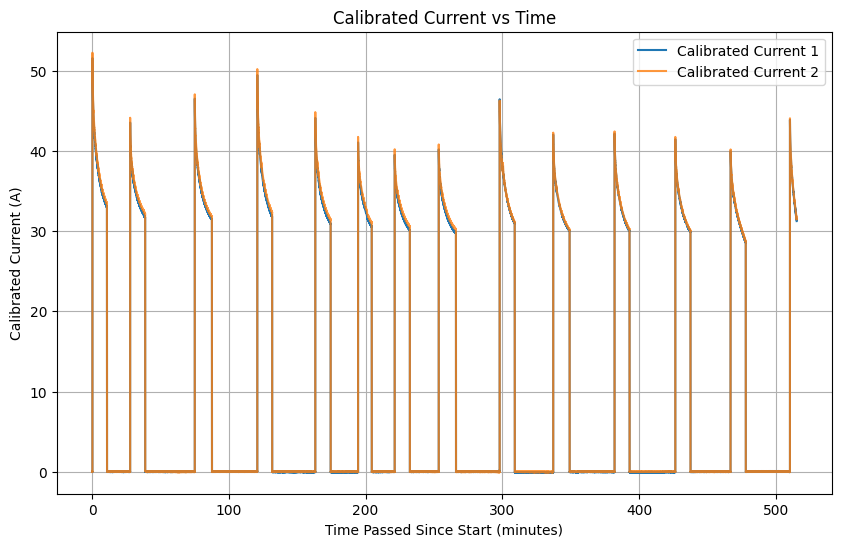

In [63]:
combined_df['Calibrated Current 1'] = combined_df['ADS Reading 1 (Smoothed and Offset)'].apply(get_calibrated_current)
combined_df['Calibrated Current 2'] = combined_df['ADS Reading 2 (Smoothed and Offset)'].apply(get_calibrated_current)
plt.figure(figsize=(10, 6))
plt.plot(combined_df['Translated Time (minutes)'], combined_df['Calibrated Current 1'], label='Calibrated Current 1')
plt.plot(combined_df['Translated Time (minutes)'], combined_df['Calibrated Current 2'], label='Calibrated Current 2', alpha=0.8)
plt.xlabel('Time Passed Since Start (minutes)')
plt.ylabel('Calibrated Current (A)')
plt.title('Calibrated Current vs Time')
plt.legend()
plt.grid()
plt.show()

In [64]:
def trapezoidal_integration(time_series_ms, current_series_A):
    total_charge = 0
    for i in range(1, len(time_series_ms)):
        delta_time = (time_series_ms[i] - time_series_ms[i-1]) / 1000  # Convert ms to seconds
        average_current = (current_series_A[i] + current_series_A[i-1]) / 2
        total_charge += average_current * delta_time
    return total_charge

In [65]:
total_charge_1 = trapezoidal_integration(combined_df['Translated Time'], combined_df['Calibrated Current 1'])
total_charge_2 = trapezoidal_integration(combined_df['Translated Time'], combined_df['Calibrated Current 2'])


In [66]:
print("Total charge calculated from Calibrated Current 1 (Coulombs):", total_charge_1)
print("Total charge calculated from Calibrated Current 2 (Coulombs):", total_charge_2)
print("Capacity in Ah:", total_charge_1 / 3600, total_charge_2 / 3600)


Total charge calculated from Calibrated Current 1 (Coulombs): 307418.9107980352
Total charge calculated from Calibrated Current 2 (Coulombs): 311143.9295418049
Capacity in Ah: 85.39414188834311 86.42886931716802
